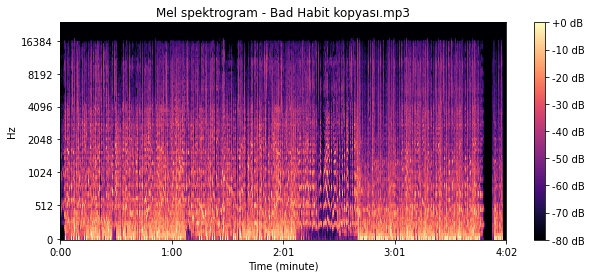

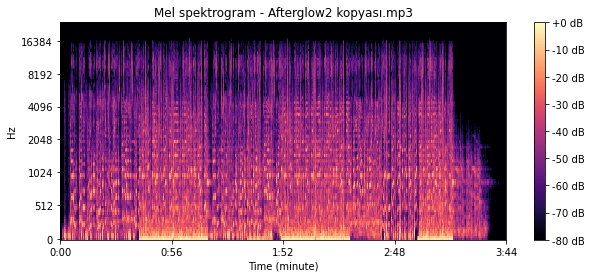

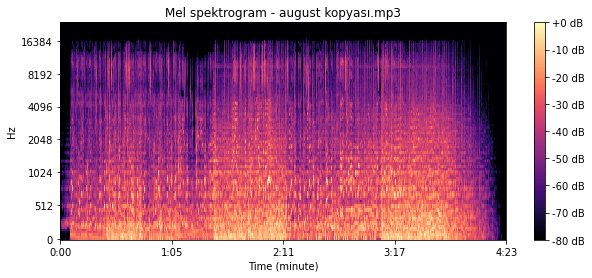

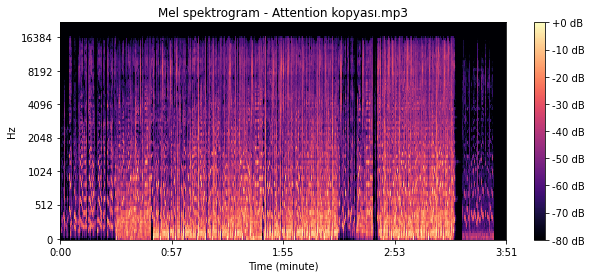

In [1]:
import librosa
import numpy as np
import os
import matplotlib.pyplot as plt
import librosa.display

# MP3 dosyalarının bulunduğu klasörü belirtin
folder_path = 'mp3_files'

# Klasördeki tüm dosyaların listesini alın ve sadece MP3 dosyalarını filtreleyin
mp3_files = [file for file in os.listdir(folder_path) if file.endswith('.mp3')]

# Her bir MP3 dosyası için işlem yapın
for mp3_file in mp3_files:
    # Dosya yolu oluşturun
    audio_filename = os.path.join(folder_path, mp3_file)
    
    # Ses dosyasını yükle
    y, sr = librosa.load(audio_filename, sr=None)
    
    # Şarkı süresini al
    duration = librosa.get_duration(y=y, sr=sr)
    duration_minutes = duration / 60  # Süreyi dakika cinsine dönüştür
    
    # Mel spektrogramını hesapla
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr)
    
    # Zamanı hesapla
    times = librosa.times_like(mel_spec, sr=sr)
    
    # Spektrogramu görselleştir
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(librosa.power_to_db(mel_spec, ref=np.max),
                              y_axis='mel', x_axis='time', sr=sr)  # Örnekleme oranını belirt
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Mel spektrogram - {mp3_file}')
    plt.xlabel('Time (minute)')
    plt.xticks(np.linspace(0, times[-1], num=5), rotation=0)
    #plt.text(times[-1], -50, f'{duration_minutes:.2f} dakika', ha='right', va='center')
    plt.show()